Running the block below, we ensure the modules are working well together and with the right version.

In [1]:
import numpy as np
import tensorflow as tf
import skimage
import pywt
import scipy


print(f"✅ NumPy: {np.__version__} (Compatible con TF)")
print(f"✅ Skimage: {skimage.__version__}")
print(f"✅ SciPy: {scipy.__version__}")
print(f"🚀 GPU: {tf.config.list_physical_devices('GPU')}")

2026-03-14 19:52:29.830063: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-14 19:52:29.869107: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-14 19:52:30.338074: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


✅ NumPy: 1.23.5 (Compatible con TF)
✅ Skimage: 0.20.0
✅ SciPy: 1.10.1
🚀 GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-03-14 19:52:31.254353: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-14 19:52:31.296774: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-03-14 19:52:31.296826: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


We run next block for ensuring WSL uses just the necessary and avoid getting the PC out of memory for background apps.

In [2]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# SEED Dataset

From: https://www.kaggle.com/datasets/sumairaziz/seed-power-quality-disturbance-dataset

Once we create a folder, we add all the .csv files.
Then we proceed to:
1. Apply Continuous Wavelet Transform
2. Normalize mathematically to 0-255
3. Resize to 128x128
4. Apply the 'jet' colormap to create a 3-channel RGB image
5. Save the image

In [ ]:
import os
import numpy as np
import pandas as pd
import pywt
import cv2

def process_seed_dataset_raw(csv_folder="SEED_CSV_Data", output_dir="seed_spectrograms_raw"):
    """
    Reads the 17 SEED dataset CSV files, applies standard CWT, 
    and saves them as raw RGB images with the 'jet' colormap (No CLAHE).
    """
    classes = [
        "Pure_Sinusoidal", "Sag", "Swell", "Interruption", "Transient", 
        "Oscillatory_Transient", "Harmonics", "Harmonics_with_Sag", 
        "Harmonics_with_Swell", "Flicker", "Flicker_with_Sag", 
        "Flicker_with_Swell", "Sag_with_Oscillatory_Transient", 
        "Swell_with_Oscillatory_Transient", "Sag_with_Harmonics", 
        "Swell_with_Harmonics", "Notch"
    ]
    
    for cls_name in classes:
        os.makedirs(os.path.join(output_dir, cls_name), exist_ok=True)
        
    print(f"Generating RAW SEED Spectrograms in: {os.path.abspath(output_dir)}")
    
    scales = np.arange(1, 128)
    wavelet = 'cmor'
    target_size = (128, 128)
    
    for class_idx, class_name in enumerate(classes):
        csv_path = os.path.join(csv_folder, f"{class_name}.csv")
        
        if not os.path.exists(csv_path):
            print(f"Warning: Could not find {csv_path}. Skipping.")
            continue
            
        print(f"Processing Class {class_idx + 1}/17: {class_name}...")
        df = pd.read_csv(csv_path, header=None)
        signals = df.values
        
        for i in range(len(signals)):
            signal = signals[i]
            
            # 1. Apply CWT
            coeffs, _ = pywt.cwt(signal, scales, wavelet)
            power = np.abs(coeffs)**2
            
            # 2. Normalize mathematically to 0-255
            power_scaled = cv2.normalize(power, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
            
            # 3. Resize to 128x128
            power_resized = cv2.resize(power_scaled, target_size, interpolation=cv2.INTER_CUBIC)
            
            # 4. Apply the 'jet' colormap to create a 3-channel RGB image
            power_color = cv2.applyColorMap(power_resized, cv2.COLORMAP_JET)
            
            # 5. Save the raw image
            filename = os.path.join(output_dir, class_name, f"{class_name}_{i:04d}.png")
            cv2.imwrite(filename, power_color)

    print("\nRaw SEED Dataset generation completely successfully!")

if __name__ == "__main__":
    process_seed_dataset_raw()

Generating RAW SEED Spectrograms in: /mnt/c/py/ArtificialVision/seed_spectrograms_raw
Processing Class 1/17: Pure_Sinusoidal...


/home/mauro_wsl/miniconda3/envs/vision_gpu/lib/python3.10/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


Processing Class 2/17: Sag...


/home/mauro_wsl/miniconda3/envs/vision_gpu/lib/python3.10/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


Processing Class 3/17: Swell...


...

Processing Class 16/17: Swell_with_Harmonics...


/home/mauro_wsl/miniconda3/envs/vision_gpu/lib/python3.10/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)


Processing Class 17/17: Notch...


/home/mauro_wsl/miniconda3/envs/vision_gpu/lib/python3.10/site-packages/pywt/_cwt.py:117: FutureWarning: Wavelets from the family cmor, without parameters specified in the name are deprecated. The name should follow the format cmorB-C, where B and C are floats representing the bandwidth frequency and center frequency, respectively (example, for backward compatibility: cmor = cmor1.0-0.5).
  wavelet = DiscreteContinuousWavelet(wavelet)



Raw SEED Dataset generation completely successfully!


# Training the 17-Class CNN

Now we train using the generated 2D dataset.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from sklearn.metrics import classification_report

# 1. Dataset Configuration
batch_size = 32
img_height = 128
img_width = 128
data_dir = "seed_spectrograms_raw" # Pointing to the RAW images

print("Loading RAW SEED datasets...")
# Load as standard RGB (3 channels)
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  color_mode='rgb', # Standard RGB
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  color_mode='rgb', # Standard RGB
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names

# Standard optimization (No SpecAugment mapped here)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

# 2. Standard CNN Architecture
model = models.Sequential([
  # Input is now 3 channels (RGB)
  layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  
  layers.Flatten(),
  layers.Dense(256, activation='relu'),
  layers.Dropout(0.4),
  layers.Dense(17) # 17 Classes
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# 3. Train the Network
epochs = 25
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

# 4. Evaluation
y_true = np.concatenate([y for x, y in val_ds], axis=0)
predictions = model.predict(val_ds)
y_pred = np.argmax(predictions, axis=1)

print("\n--- RAW Baseline CNN Results ---")
print(classification_report(y_true, y_pred, target_names=class_names))

Loading RAW SEED datasets...
Found 17000 files belonging to 17 classes.
Using 13600 files for training.
Found 17000 files belonging to 17 classes.
Using 3400 files for validation.
Epoch 1/25


2026-03-14 20:08:50.219890: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [13600]
	 [[{{node Placeholder/_0}}]]
2026-03-14 20:08:50.220144: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [13600]
	 [[{{node Placeholder/_0}}]]


424/425 [============================>.] - ETA: 0s - loss: 2.1360 - accuracy: 0.2714

2026-03-14 20:09:07.313579: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [3400]
	 [[{{node Placeholder/_0}}]]
2026-03-14 20:09:07.313824: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [3400]
	 [[{{node Placeholder/_4}}]]


425/425 [==============================] - 18s 25ms/step - loss: 2.1354 - accuracy: 0.2717 - val_loss: 1.7843 - val_accuracy: 0.3650
Epoch 2/25
425/425 [==============================] - 10s 24ms/step - loss: 1.7801 - accuracy: 0.3549 - val_loss: 1.5924 - val_accuracy: 0.4071
Epoch 3/25
425/425 [==============================] - 12s 28ms/step - loss: 1.6382 - accuracy: 0.3963 - val_loss: 1.4593 - val_accuracy: 0.4494
Epoch 4/25
425/425 [==============================] - 10s 24ms/step - loss: 1.4913 - accuracy: 0.4521 - val_loss: 1.2644 - val_accuracy: 0.5365
Epoch 5/25
425/425 [==============================] - 10s 23ms/step - loss: 1.3218 - accuracy: 0.5176 - val_loss: 1.1294 - val_accuracy: 0.5850
Epoch 6/25
425/425 [==============================] - 10s 23ms/step - loss: 1.1832 - accuracy: 0.5707 - val_loss: 1.0165 - val_accuracy: 0.6421
Epoch 7/25
425/425 [==============================] - 12s 28ms/step - loss: 1.1072 - accuracy: 0.5988 - val_loss: 0.9962 - val_accuracy: 0.6571
Epo

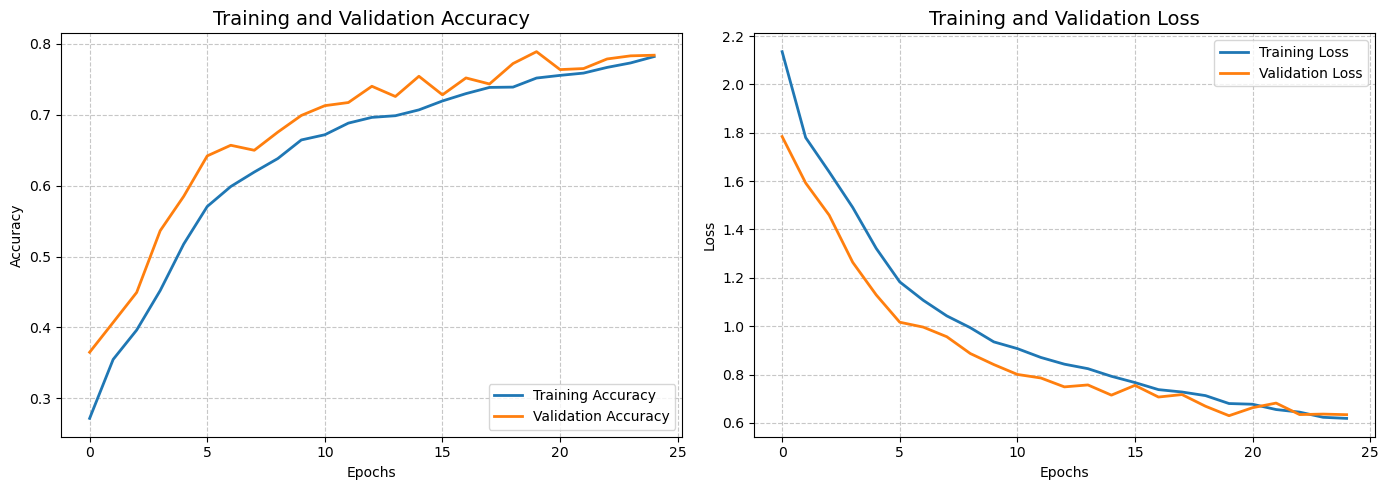

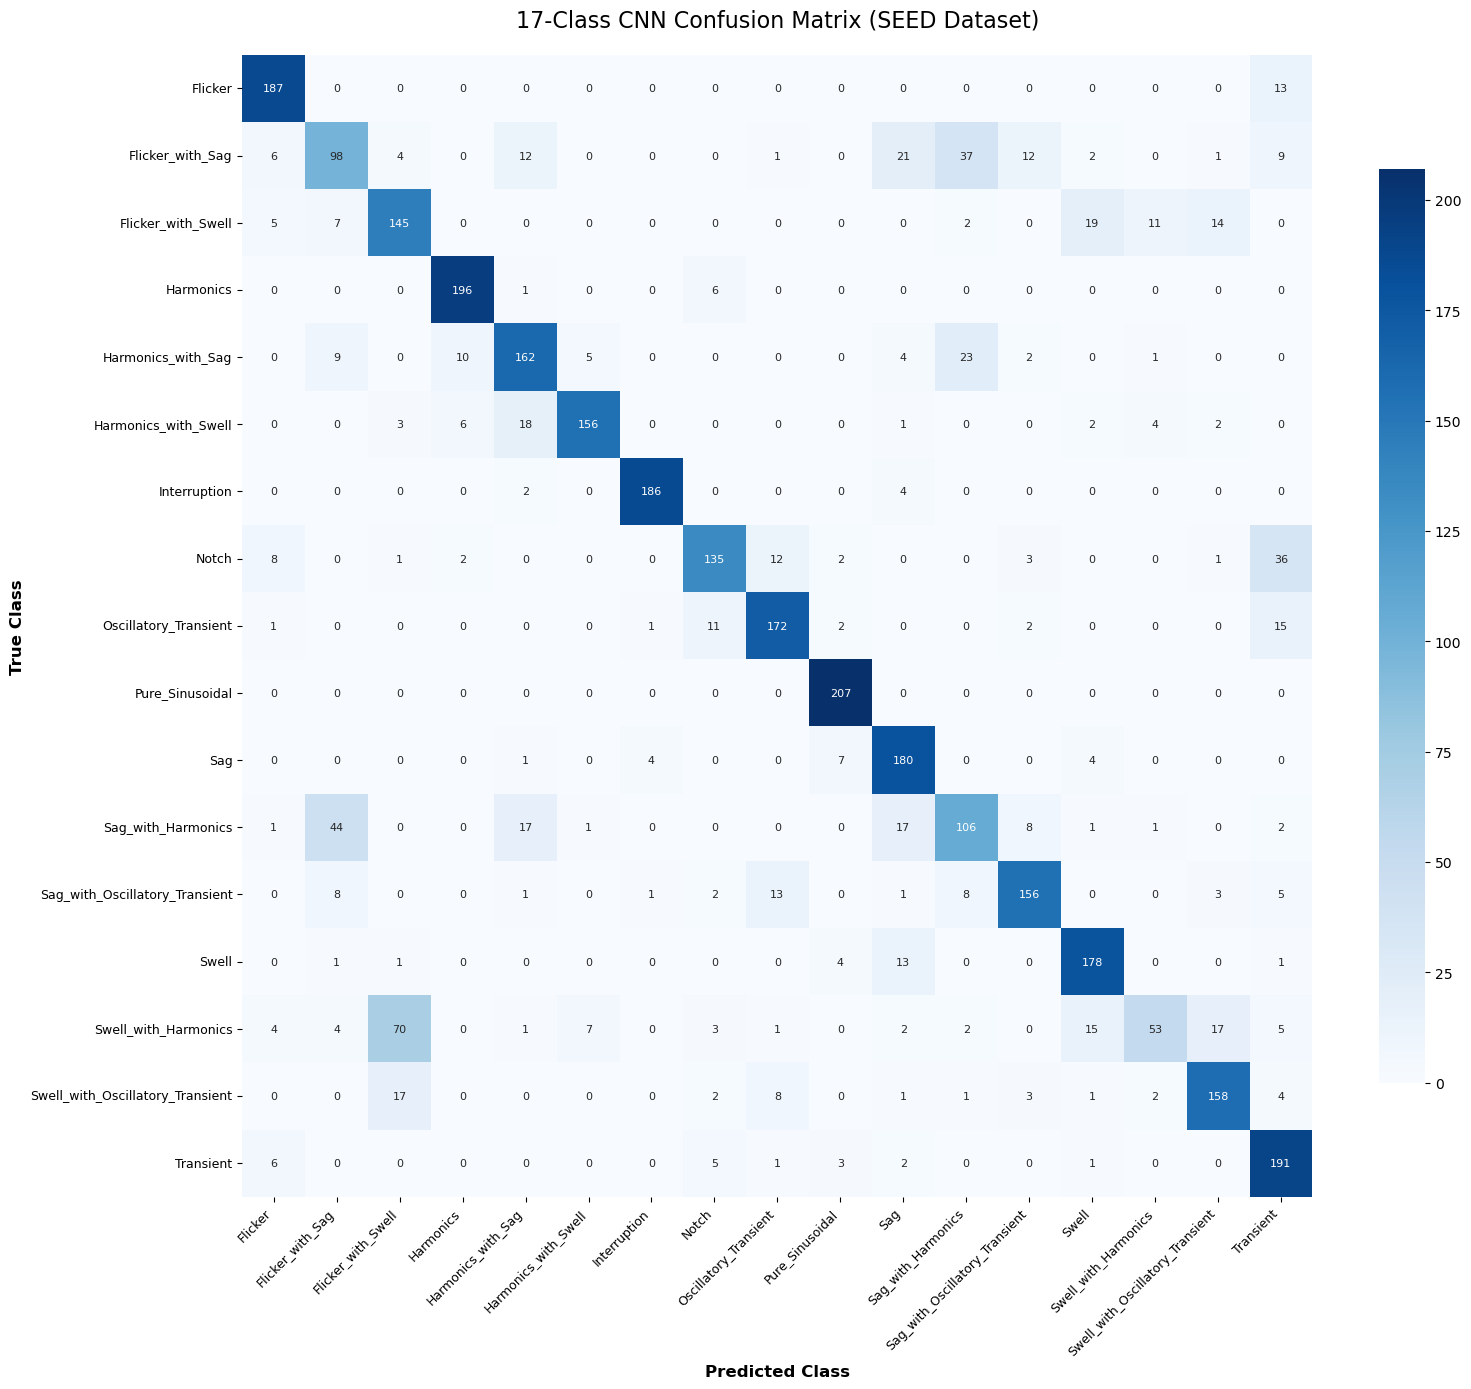

In [9]:
# 5. Visualizations for the 17-Class CNN
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Extract metrics from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# --- Plot A: Accuracy & Loss Curves ---
plt.figure(figsize=(14, 5))

# Accuracy Subplot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)

# Loss Subplot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.legend(loc='upper right')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('seed_learning_curves.png', dpi=300) # Save high-res for the report
plt.show()

# --- Plot B: 17-Class Confusion Matrix ---
# Generate the matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Set up a very large figure size to accommodate the 17x17 grid
plt.figure(figsize=(16, 14))

# Use a heatmap with smaller annotation text to fit the numbers
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 8}, cbar_kws={'shrink': 0.8})

plt.title('17-Class CNN Confusion Matrix (SEED Dataset)', fontsize=16, pad=20)
plt.ylabel('True Class', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')

# Rotate the x-axis labels so the long names are readable
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.savefig('seed_confusion_matrix.png', dpi=300, bbox_inches='tight') # Save high-res for the report
plt.show()

We obtain more reliable results compared with the synthetic data.
- Acceptable results obtained with a 25 epoches - training.
- The conffusion matrix helps us identify the exact mistake for each class.
- For 17 classes we can reach an accuracy of 78%

# Proposed Improvements for the next delicery

- Include more existing datasets.
- Make comparisson with other classifiers, including non DL approaches like SVM.
- Preprocessing improvements:
    1. SpecAugment (Time and Frequency Masking)

    2. CLAHE (Contrast Limited Adaptive Histogram Equalization)

    3. Grayscale Conversion vs. Colormaps

